# 4. Ground and height

Classify ground returns, interpolate a terrain model, and turn elevations into
heights above ground.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import canopy, filters, ground

cloud = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.05)

## Ground classification

Two filters: the cloth simulation filter (CSF, Zhang et al. 2016) drapes a
cloth over the inverted cloud; the progressive morphological filter (PMF,
Zhang et al. 2003) opens a minimum surface with growing windows.

The tile's own `classification` came from PMF (see `make_litch_subset.py`), so
compare the two directly. CSF puts the terrain metres too high in about 8 % of
cells here, and the map below shows where: a band along the tile boundary. The
cloth is a connected sheet, so it needs points on both sides to be pulled down;
at a cut edge it has nothing to hold it and rides up on the vegetation just
inside. PMF works cell by cell and is unaffected.

In [2]:
csf = ground.ground_mask(ground.classify_ground_csf(cloud))
pmf = ground.ground_mask(ground.classify_ground_pmf(cloud))
for name, m in (("CSF", csf), ("PMF", pmf)):
    print(f"{name}: {m.sum():>8,} ground points ({m.mean():.1%}); "
          f"highest ground point {cloud.z[m].max():5.2f} m")

dtm_csf = ground.make_dtm(cloud.with_attrs(classification=np.where(csf, 2, 1).astype("uint8")), 0.5, bounds=(0, 0, 20, 20))
dtm = ground.make_dtm(cloud.with_attrs(classification=np.where(pmf, 2, 1).astype("uint8")), 0.5, bounds=(0, 0, 20, 20))
diff = dtm_csf.data - dtm.data
print(f"CSF above PMF by more than 0.5 m in {np.mean(diff > 0.5):.1%} of cells, "
      f"95th percentile {np.nanpercentile(diff, 95):.1f} m")

CSF:  261,931 ground points (17.4%); highest ground point 15.72 m
PMF:  283,533 ground points (18.8%); highest ground point  0.48 m
CSF above PMF by more than 0.5 m in 7.6% of cells, 95th percentile 5.1 m


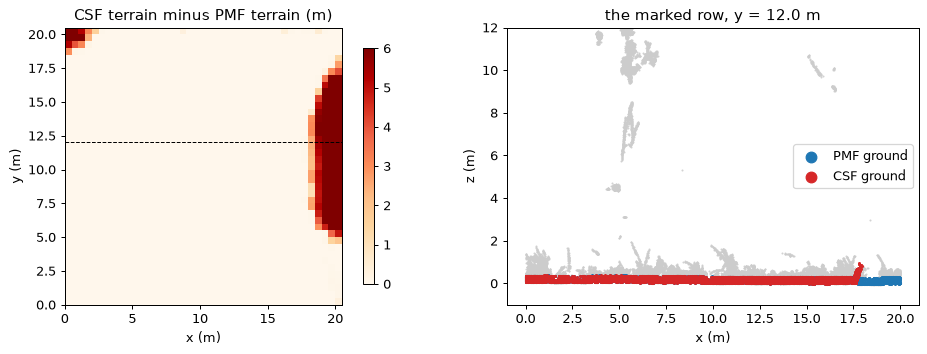

In [3]:
row = int(np.nanargmax(np.nan_to_num(diff).max(axis=1)))       # the worst row of the difference
y0 = dtm.ymin + row * dtm.resolution
slab = (cloud.y > y0 - 0.5) & (cloud.y < y0 + 0.5)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(diff, origin="lower", extent=(dtm.xmin, dtm.xmax, dtm.ymin, dtm.ymax),
                  cmap="OrRd", vmin=0, vmax=6)
ax[0].axhline(y0, color="k", lw=0.8, ls="--")
ax[0].set(title="CSF terrain minus PMF terrain (m)", xlabel="x (m)", ylabel="y (m)")
fig.colorbar(im, ax=ax[0], shrink=0.85)
ax[1].scatter(cloud.x[slab], cloud.z[slab], s=0.3, c="0.8")
for m, name, c, size in ((pmf, "PMF ground", "C0", 2.0), (csf, "CSF ground", "C3", 2.0)):
    ax[1].scatter(cloud.x[slab & m], cloud.z[slab & m], s=size, c=c, label=name)
ax[1].set(title=f"the marked row, y = {y0:.1f} m", xlabel="x (m)", ylabel="z (m)", ylim=(-1, 12))
ax[1].legend(markerscale=6);

The diagnosis is testable: crop the cloud further in and the bad band
should follow the new edge, which is what happens. Distance of the disagreeing
cells from whichever boundary the cloud was cut at:

In [4]:
for lo, hi, label in ((0, 20, "full tile"), (4, 16, "inner 12 x 12 m"), (7, 13, "inner 6 x 6 m")):
    sub = filters.crop_box(cloud, (lo, lo, None), (hi, hi, None))
    a = ground.make_dtm(ground.classify_ground_csf(sub), 0.5, bounds=(lo, lo, hi, hi)).data
    b = ground.make_dtm(ground.classify_ground_pmf(sub), 0.5, bounds=(lo, lo, hi, hi)).data
    bad = np.argwhere(np.nan_to_num(a - b) > 0.5)
    if not len(bad):
        print(f"{label:16s} no cell differs by more than 0.5 m")
        continue
    xs, ys = lo + bad[:, 1] * 0.5, lo + bad[:, 0] * 0.5
    edge = np.minimum(np.minimum(xs - lo, hi - xs), np.minimum(ys - lo, hi - ys))
    print(f"{label:16s} {len(bad) / a.size:5.1%} of cells disagree, "
          f"median {np.median(edge):.1f} m from the edge, 90th percentile {np.percentile(edge, 90):.1f} m")

full tile         7.6% of cells disagree, median 0.5 m from the edge, 90th percentile 2.0 m
inner 12 x 12 m  12.6% of cells disagree, median 0.5 m from the edge, 90th percentile 1.5 m
inner 6 x 6 m    no cell differs by more than 0.5 m


So the lesson is not "CSF is worse here": it is to classify ground on
the whole plot and crop afterwards, or to cut tiles with a buffer of a few
metres. Away from the edge the two filters agree to within 0.5 m on every cell
of this tile.

## DTM, heights and CHM

In [5]:
cloud = ground.normalize_height(cloud, dtm)          # adds the 'height' attribute
flat = ground.flatten(cloud, dtm)                    # or replace z itself
chm = ground.make_chm(cloud, resolution=0.5)
print("terrain relief across the tile:", round(float(np.nanmax(dtm.data) - np.nanmin(dtm.data)), 2), "m")
print("canopy height p99:", round(float(np.percentile(cloud.attrs["height"], 99)), 1), "m,",
      "max", round(float(cloud.attrs["height"].max()), 1), "m")
print("canopy cover above 2 m:", round(float(canopy.canopy_cover(chm.data, 2.0)), 3))

terrain relief across the tile: 0.34 m
canopy height p99: 18.7 m, max 20.0 m
canopy cover above 2 m: 0.683


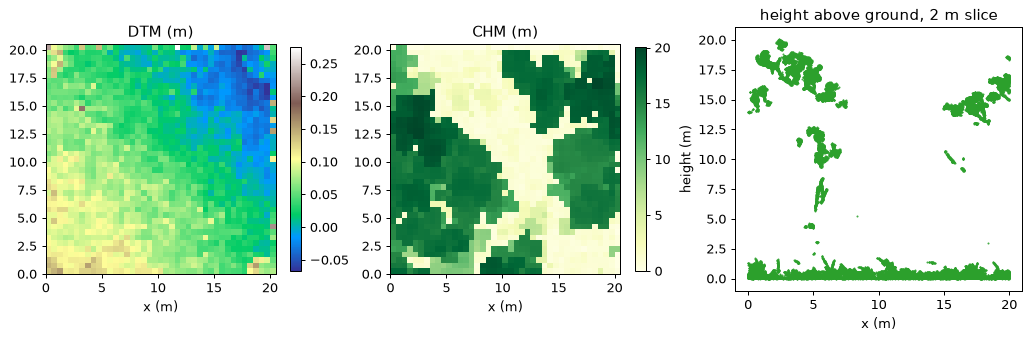

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, r, title, cmap in ((ax[0], dtm, "DTM (m)", "terrain"), (ax[1], chm, "CHM (m)", "YlGn")):
    im = a.imshow(r.data, origin="lower", extent=(r.xmin, r.xmax, r.ymin, r.ymax), cmap=cmap)
    a.set(title=title, xlabel="x (m)"); fig.colorbar(im, ax=a, shrink=0.85)
ax[2].scatter(cloud.x[slab], cloud.attrs["height"][slab], s=0.3, c="C2")
ax[2].set(title="height above ground, 2 m slice", xlabel="x (m)", ylabel="height (m)");

Rasters export to an ESRI ASCII grid, or to GeoTIFF with
`dtm.to_geotiff("dtm.tif", crs="EPSG:28352")` when `rasterio` is installed
(`pip install sylva-rs[geotiff]`). Pass the same `bounds` on every date so a
time series lines up.

In [7]:
chm.to_ascii_grid("chm.asc")
sylva.write(cloud, "tile_normalized.laz")       # keeps 'height' as an extra-bytes dimension
print(sorted(sylva.read("tile_normalized.laz").attrs))

['classification', 'gps_time', 'height', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data']
